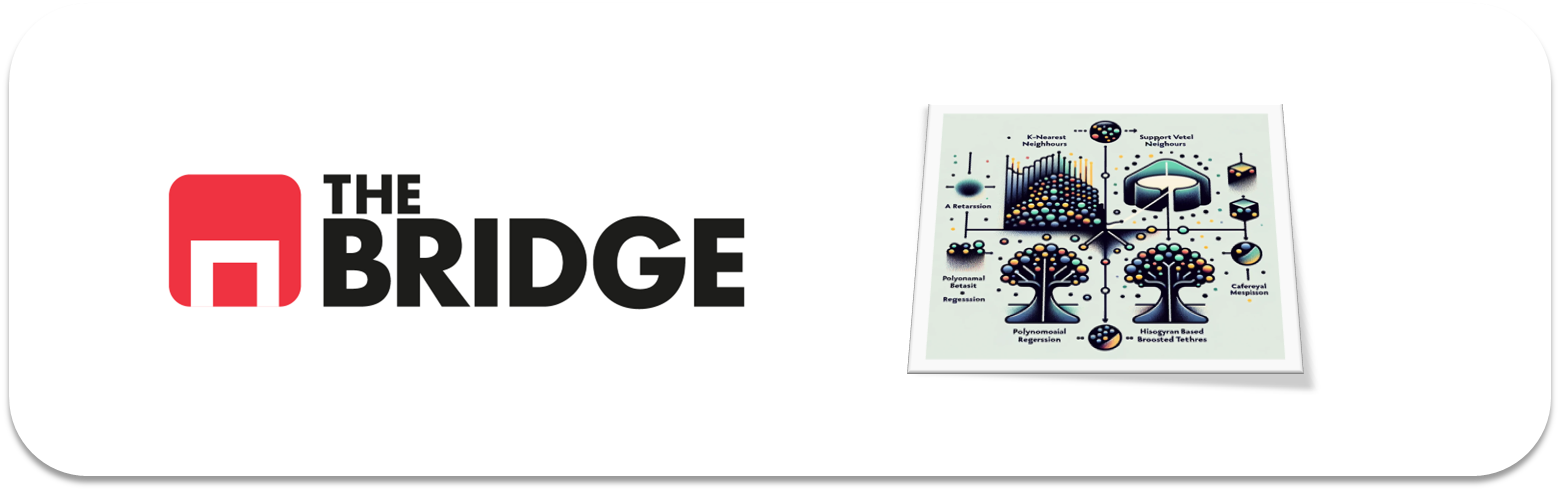

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [298]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
 
from imblearn.over_sampling import SMOTE # Nuevos amigos para ayudaros
from imblearn.under_sampling import RandomUnderSampler # Nuevos amigos para ayudarnos
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [299]:
df = pd.read_csv("./data/wines_dataset.csv",sep="|")

In [300]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [301]:
target_c = "quality"
target_r = "alcohol"

In [302]:
df[target_c].value_counts(normalize=True)

quality
6    0.436509
5    0.329075
7    0.166077
4    0.033246
8    0.029706
3    0.004618
9    0.000770
Name: proportion, dtype: float64

<Axes: xlabel='alcohol', ylabel='Count'>

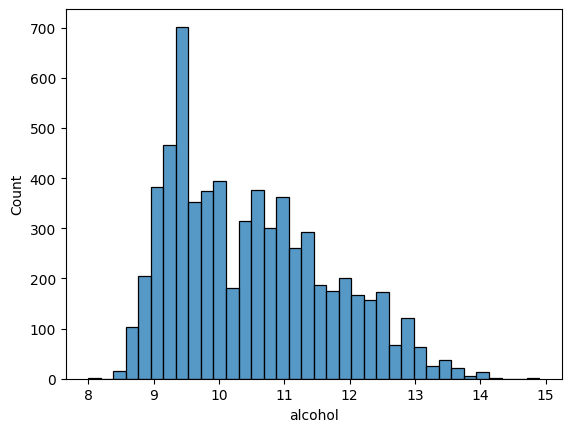

In [303]:
sns.histplot(df[target_r])

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [305]:
df_class = df.copy()

In [306]:
diccionario = {3:0,4:1,5:2,6:3,7:4,8:5,9:6}
df_class[target_c] = df_class[target_c].map(diccionario)

In [307]:
df_class_train,df_class_test = train_test_split(df_class, train_size=0.8, random_state=42)

In [308]:
df_class_train.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'class'],
      dtype='object')

In [309]:
numericas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']

In [310]:
categoricas = ["class"]

In [311]:
df_class[target_c].value_counts()

quality
3    2836
2    2138
4    1079
1     216
5     193
0      30
6       5
Name: count, dtype: int64

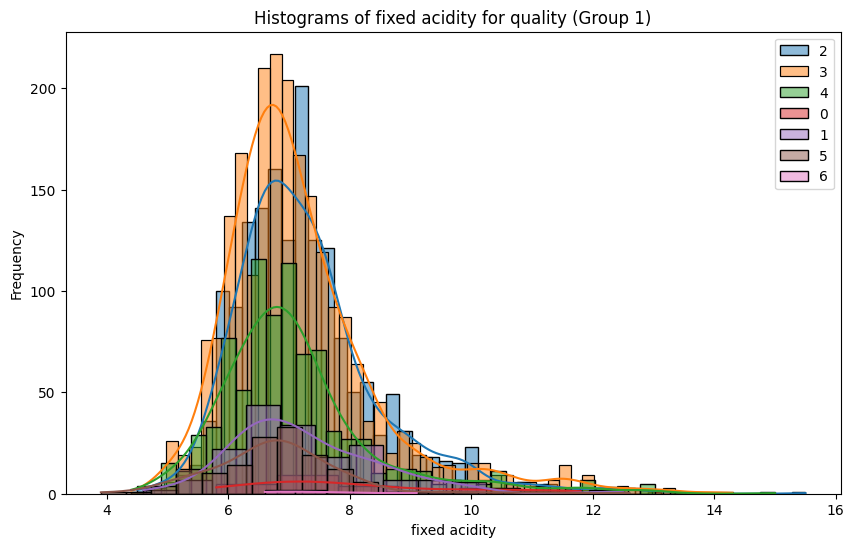

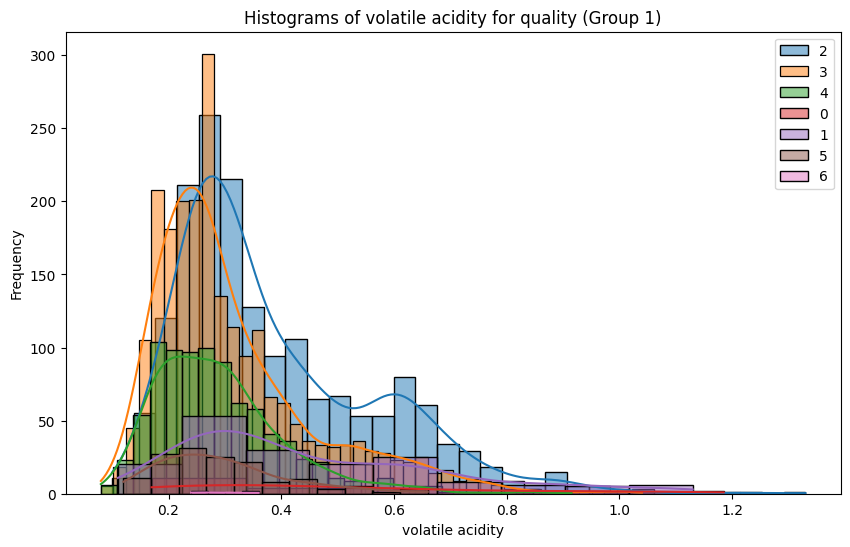

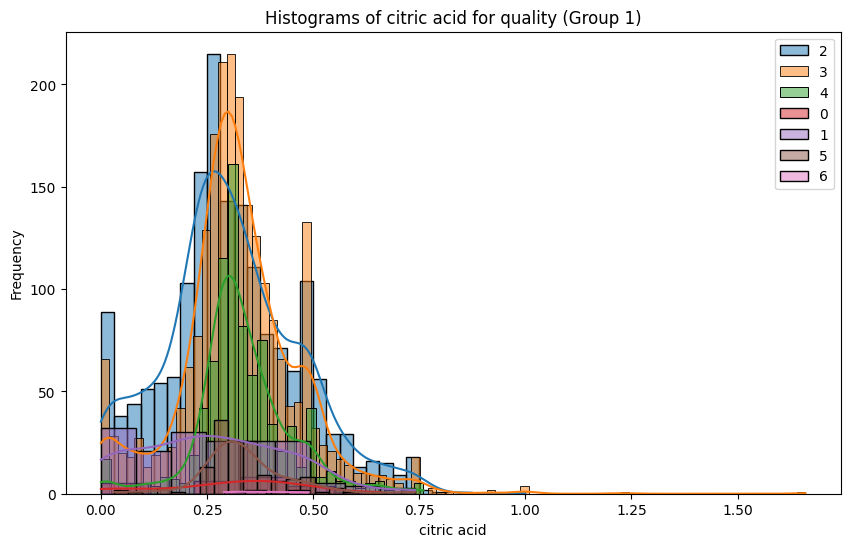

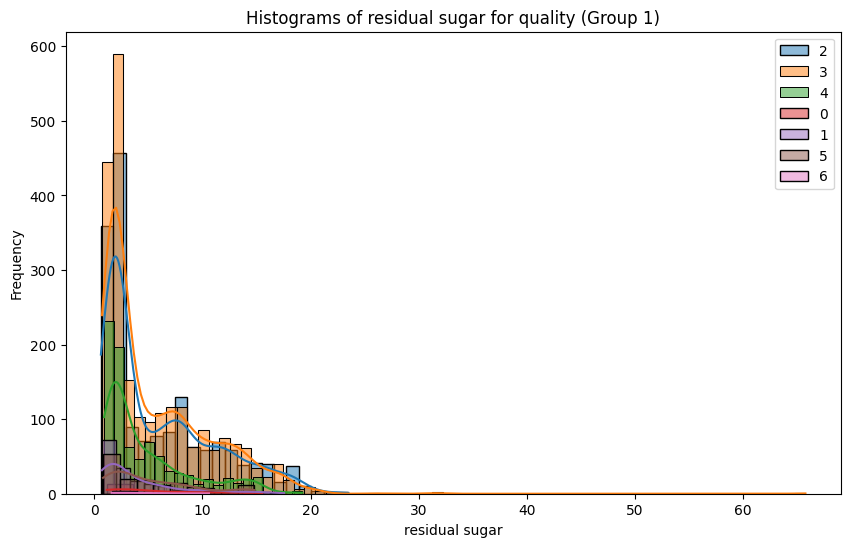

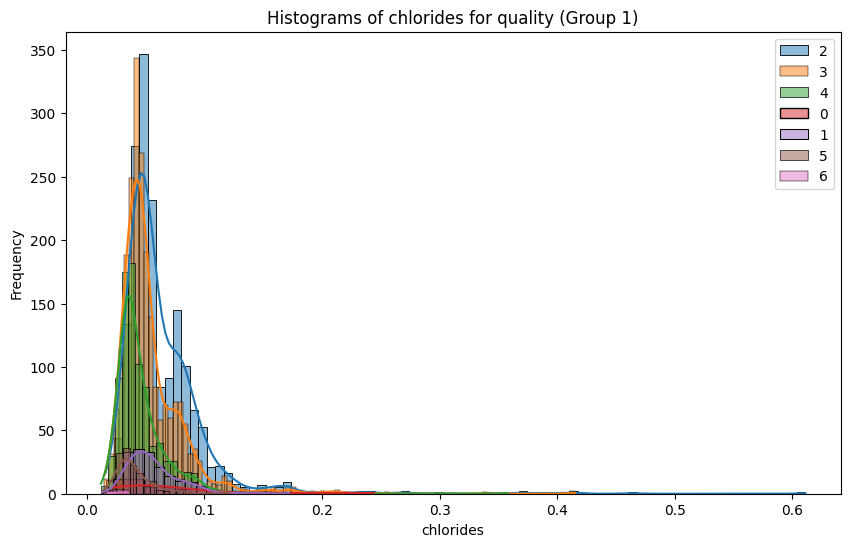

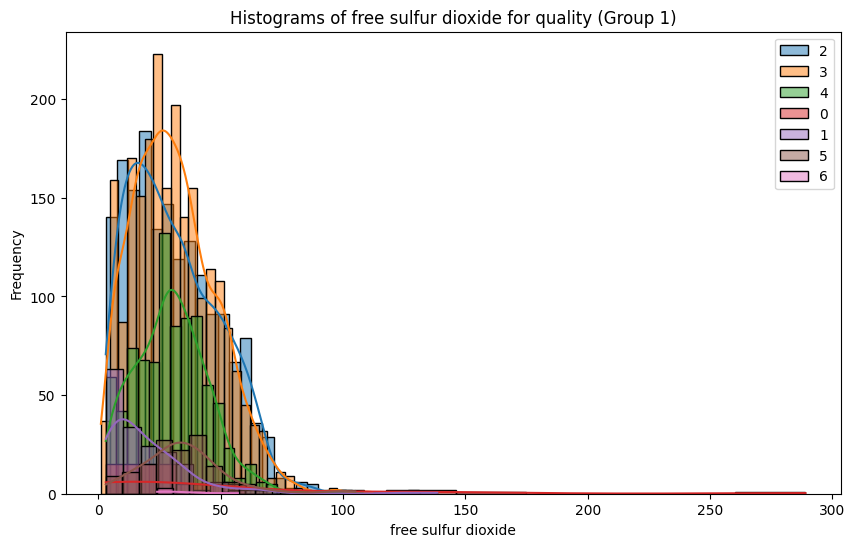

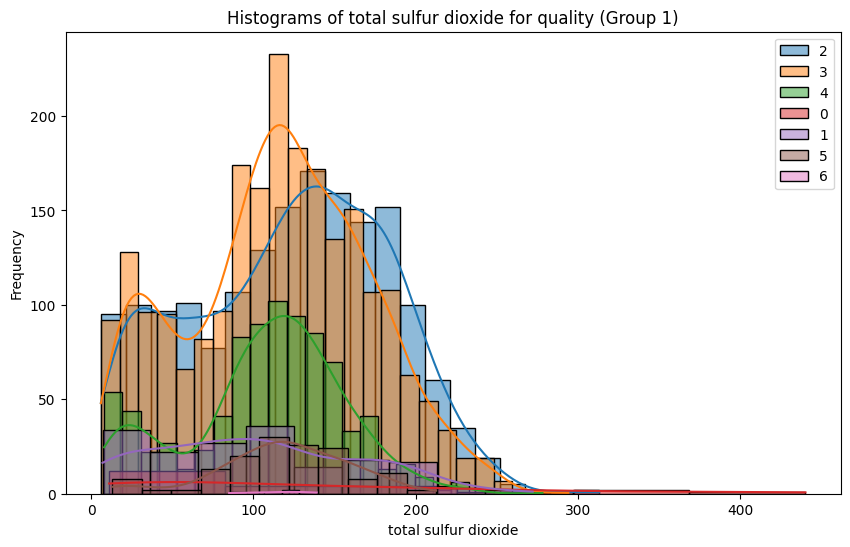

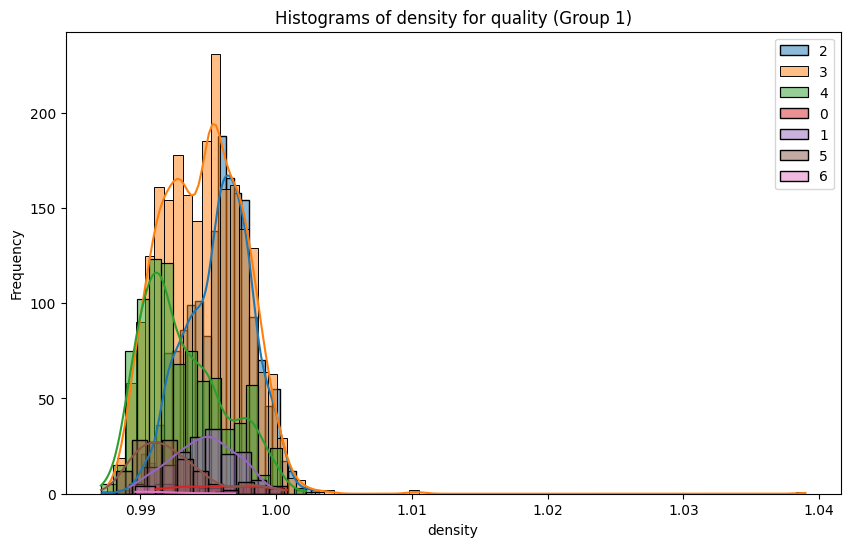

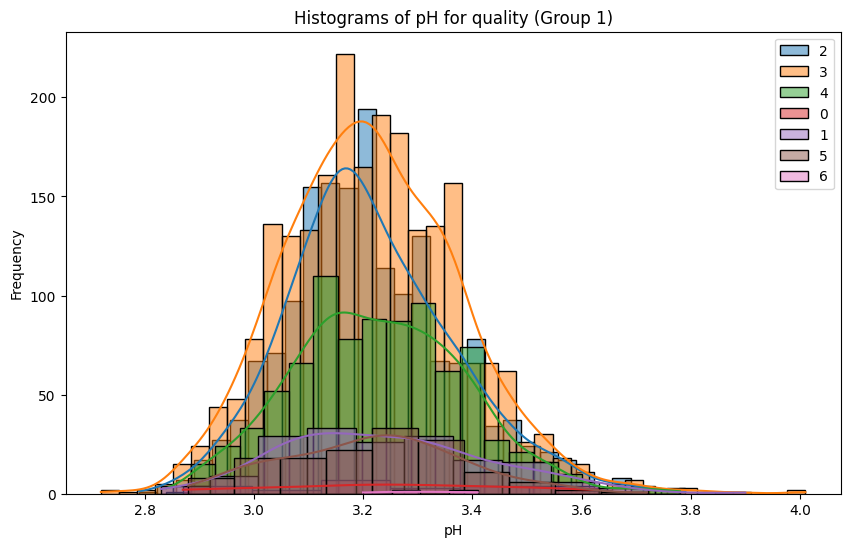

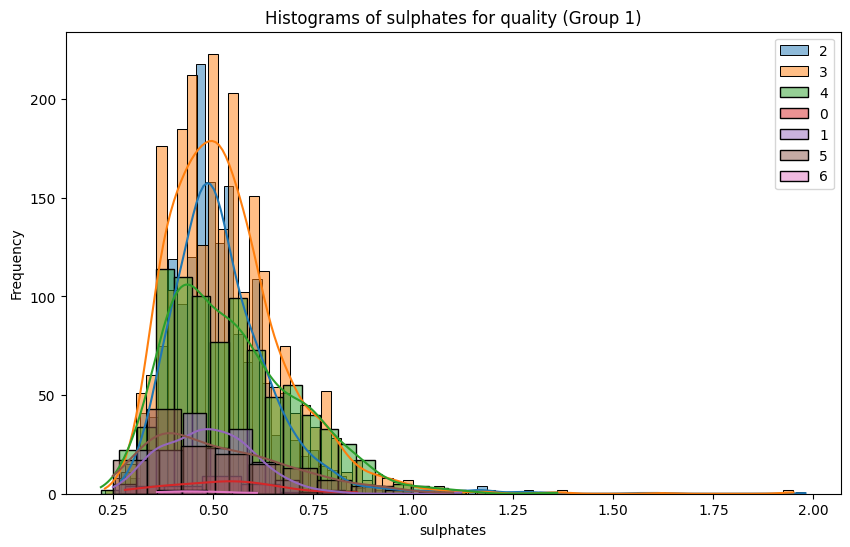

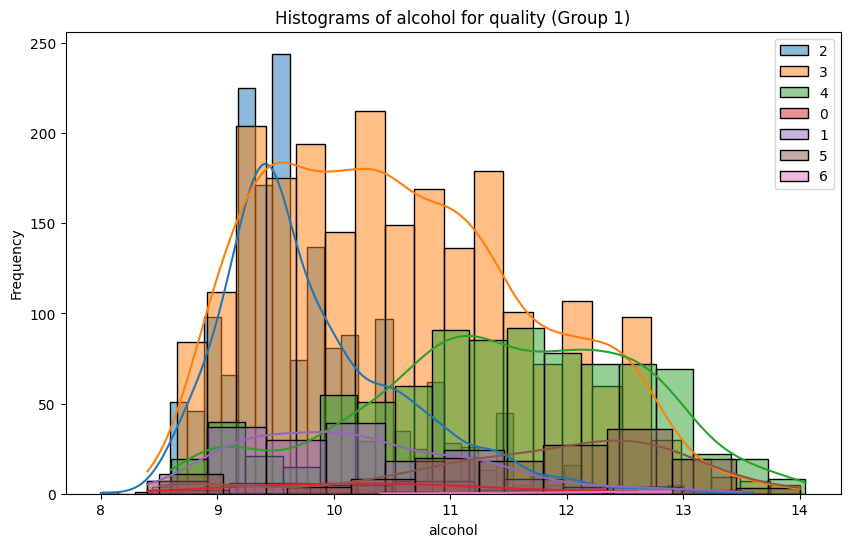

In [312]:
for numerica in numericas:    
    bt.plot_grouped_histograms(df_class_train, target_c,numerica, group_size=len(numericas))

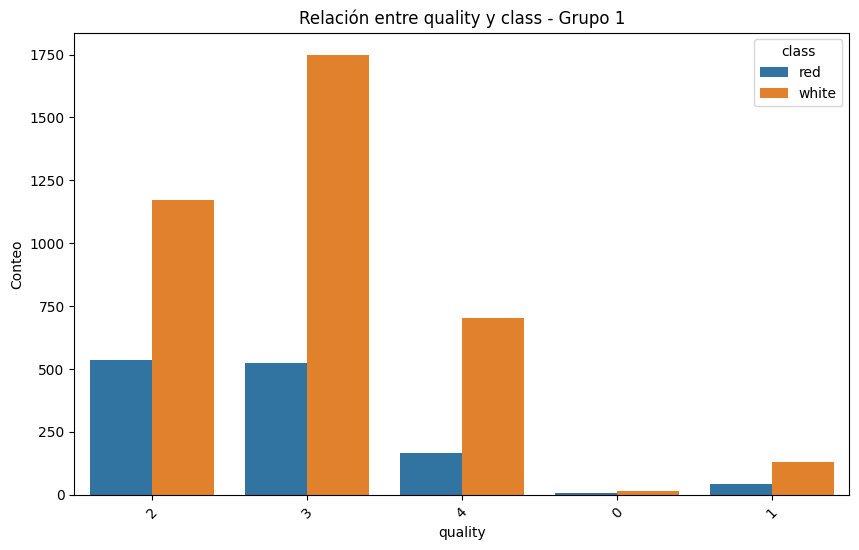

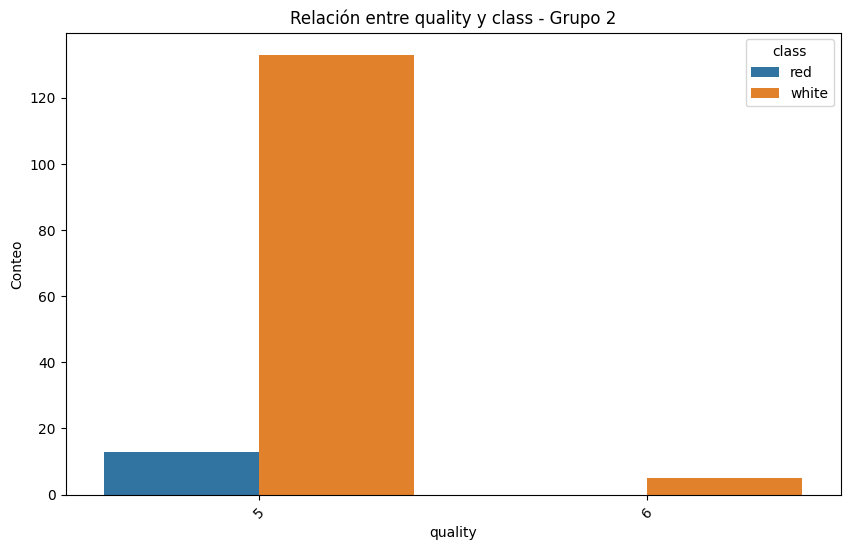

In [313]:
bt.plot_categorical_relationship_fin(df_class_train,target_c,"class")

In [314]:
df_class_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
1916,7.9,0.18,0.40,2.2,0.049,38.0,67.0,0.99600,3.33,0.93,11.3,2,red
947,7.1,0.18,0.74,15.6,0.044,44.0,176.0,0.99960,3.38,0.67,9.0,3,white
877,7.6,0.51,0.24,1.2,0.040,10.0,104.0,0.99200,3.05,0.29,10.8,3,white
2927,6.0,0.25,0.28,7.7,0.053,37.0,132.0,0.99489,3.06,0.50,9.4,3,white
6063,9.0,0.38,0.41,2.4,0.103,6.0,10.0,0.99604,3.13,0.58,11.9,4,red


In [315]:
df_class_train["class"] = df_class_train["class"]=="red"

In [ ]:
df_class_test["class"] = df_class_test["class"]=="red"


In [317]:
df_class_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
1916,7.9,0.18,0.40,2.2,0.049,38.0,67.0,0.99600,3.33,0.93,11.3,2,True
947,7.1,0.18,0.74,15.6,0.044,44.0,176.0,0.99960,3.38,0.67,9.0,3,False
877,7.6,0.51,0.24,1.2,0.040,10.0,104.0,0.99200,3.05,0.29,10.8,3,False
2927,6.0,0.25,0.28,7.7,0.053,37.0,132.0,0.99489,3.06,0.50,9.4,3,False
6063,9.0,0.38,0.41,2.4,0.103,6.0,10.0,0.99604,3.13,0.58,11.9,4,True


In [318]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'class'],
      dtype='object')

In [319]:
variables_escalar = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'sulphates']

In [ ]:
df_class_train_escalado = df_class_train.copy()


In [321]:
df_class_train_escalado[variables_escalar]=df_class_train_escalado[variables_escalar].apply(lambda x: np.log(x+0.1))

In [ ]:

df_class_test_escalado = df_class_test.copy()
df_class_test_escalado[variables_escalar]=df_class_test_escalado[variables_escalar].apply(lambda x: np.log(x+0.1))

In [323]:
from sklearn.preprocessing import StandardScaler

In [324]:
escalador = StandardScaler()
df_class_train_escalado = pd.DataFrame(escalador.fit_transform(df_class_train_escalado[numericas]),columns=df_class_train_escalado[numericas].columns, index = df_class_train_escalado[numericas].index)

In [ ]:

df_class_test_escalado = pd.DataFrame(escalador.transform(df_class_test_escalado[numericas]),columns=df_class_test_escalado[numericas].columns, index = df_class_test_escalado[numericas].index)

In [326]:
df_class_train_escalado["class"] = df_class_train["class"]

In [327]:
df_class_test_escalado["class"] = df_class_test["class"]

In [328]:
df_class_train_escalado["quality"] = df_class_train["quality"]
df_class_test_escalado["quality"] = df_class_test["quality"]

In [329]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'class']

In [330]:
x_train_class = df_class_train[features]
y_train_class = df_class_train[target_c]
x_test_class = df_class_test[features]
y_test_class = df_class_test[target_c]

In [331]:
x_train_class_escaled = df_class_train_escalado[features]
y_train_class_escaled= df_class_train_escalado[target_c]
x_test_class_escalado = df_class_test_escalado[features]
y_test_class_escalado = df_class_test_escalado[target_c]

In [332]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [333]:
from sklearn.model_selection import cross_val_score

In [336]:
balanceo_abajo = SMOTE( random_state=42,sampling_strategy="auto",k_neighbors=3)

In [337]:
x_train_class_resample,y_train_class_resample = balanceo_abajo.fit_resample(x_train_class,y_train_class.squeeze())
 
x_train_class_escaled_resample,y_train_class_escaled_resample = balanceo_abajo.fit_resample(x_train_class_escaled,y_train_class_escaled.squeeze())


In [338]:
xgbc = XGBClassifier(max_depth=10,n_estimators=300, random_state= 42 )
rfc = RandomForestClassifier(max_depth = 10, random_state= 42,n_estimators=300,n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5)

In [340]:
np.mean(cross_val_score(xgbc, x_train_class_resample, y_train_class_resample, cv=5, n_jobs=-1, scoring="balanced_accuracy"))

np.float64(0.8883733635778948)

In [ ]:
np.mean(cross_val_score(rfc, x_train_class_resample, y_train_class_resample, cv=5, n_jobs=-1, scoring="balanced_accuracy"))


np.float64(0.8070779189344325)

In [342]:
np.mean(cross_val_score(knn, x_train_class_escaled_resample, y_train_class_escaled_resample, cv=5, n_jobs=-1, scoring="balanced_accuracy"))

np.float64(0.8421395721962115)

In [354]:
scale_pos_weight = (y_train_class_resample == 0).sum() / (y_train_class_resample == 1).sum()

param_grid = {
    "n_estimators": [100, 200, 300],          # número de árboles
    "max_depth": [3, 5, 7],                   # profundidad máxima
    "learning_rate": [0.01, 0.05, 0.1],      # tasa de aprendizaje
    "gamma": [0, 0.1, 0.3],                   # regularización de nodo
    "reg_lambda": [1, 1.5, 2]}

In [344]:
from sklearn.model_selection import GridSearchCV

In [355]:
grideo = GridSearchCV(xgbc, param_grid=param_grid, cv=5, n_jobs=-1,scoring="balanced_accuracy")

In [356]:
grideo.fit(x_train_class_resample, y_train_class_resample)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [358]:
grideo.best_score_

np.float64(0.8856046030747102)

In [359]:
xgbc_f = XGBClassifier(**grideo.best_params_)

In [360]:
xgbc_f.fit(x_train_class_resample,y_train_class_resample)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [362]:
y_test_class.value_counts()

quality
3    562
2    432
4    210
5     47
1     43
0      6
Name: count, dtype: int64

In [363]:
print(classification_report(y_test_class,xgbc_f.predict(x_test_class)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.29      0.30      0.30        43
           2       0.73      0.71      0.72       432
           3       0.67      0.65      0.66       562
           4       0.54      0.63      0.58       210
           5       0.60      0.53      0.56        47
           6       0.00      0.00      0.00         0

    accuracy                           0.65      1300
   macro avg       0.40      0.40      0.40      1300
weighted avg       0.65      0.65      0.65      1300



c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

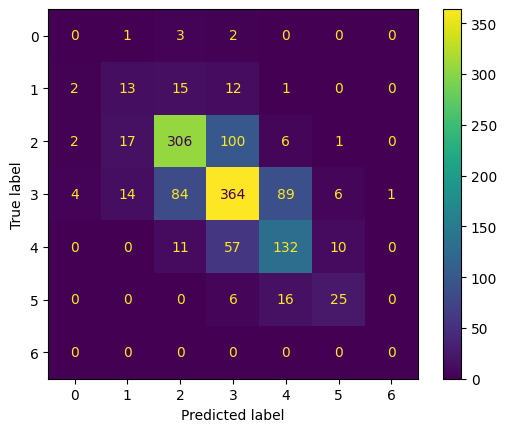

In [367]:
ConfusionMatrixDisplay.from_predictions(y_test_class,xgbc_f.predict(x_test_class))

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [372]:
categoricas2 = ["class","quality"]

In [368]:
df_reg = df.copy()

In [369]:
df_reg_train,df_reg_test = train_test_split(df_reg, train_size=0.8, random_state=42)

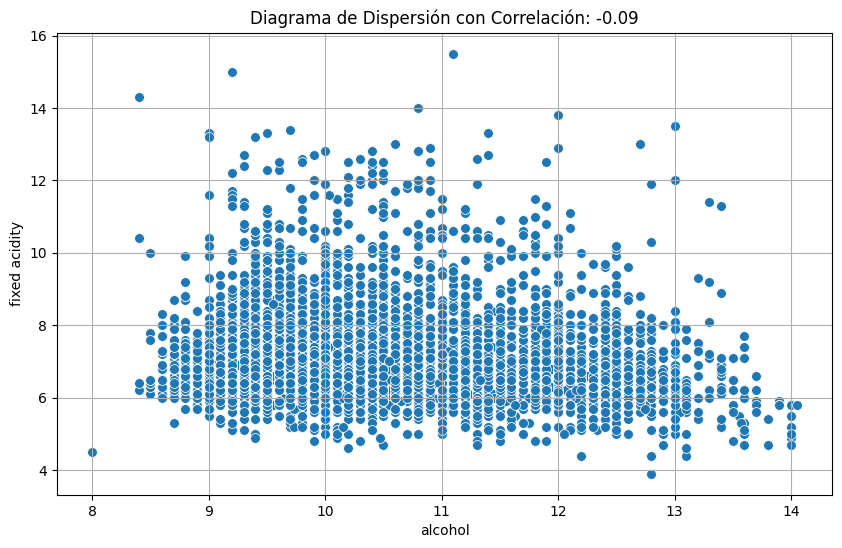

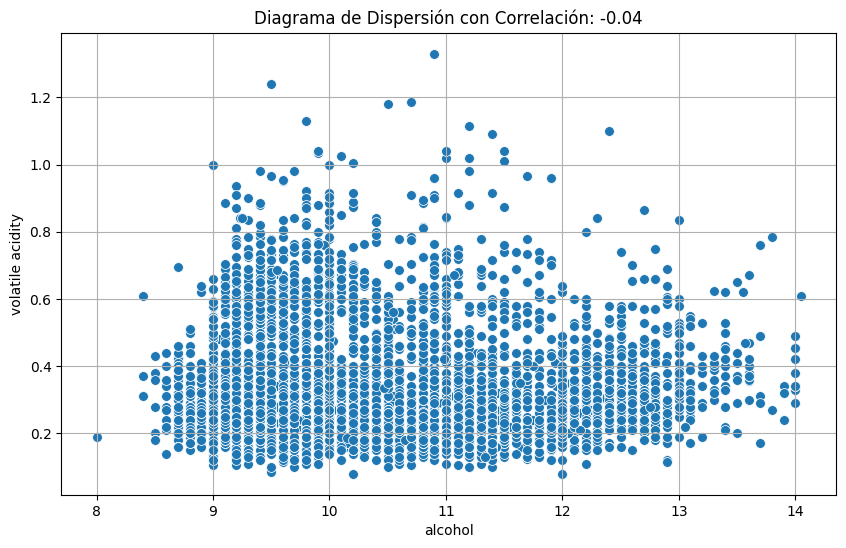

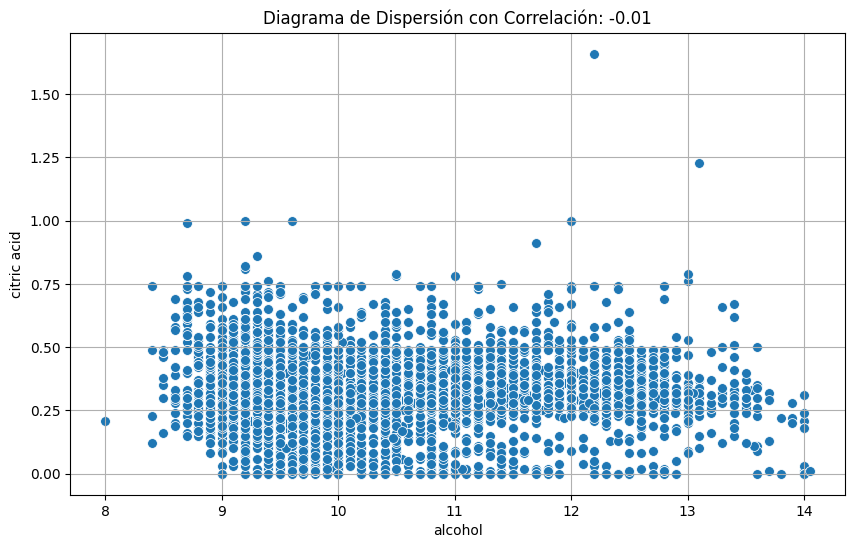

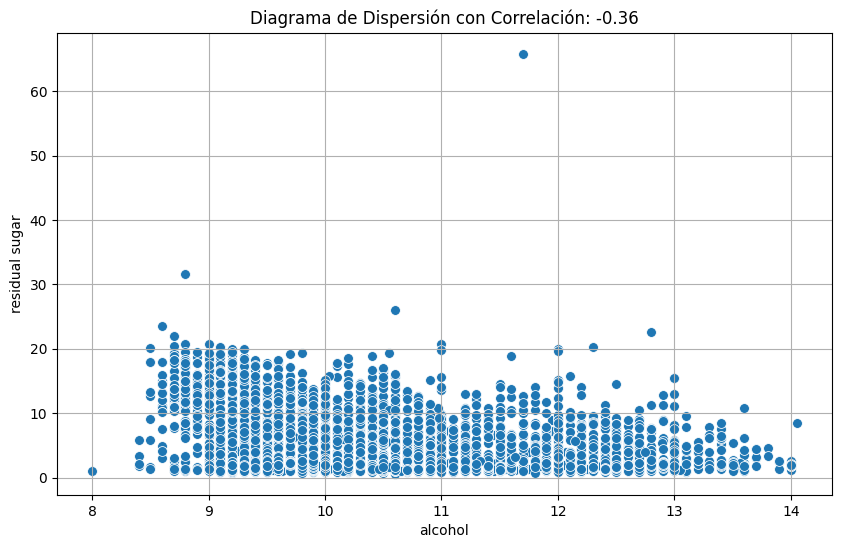

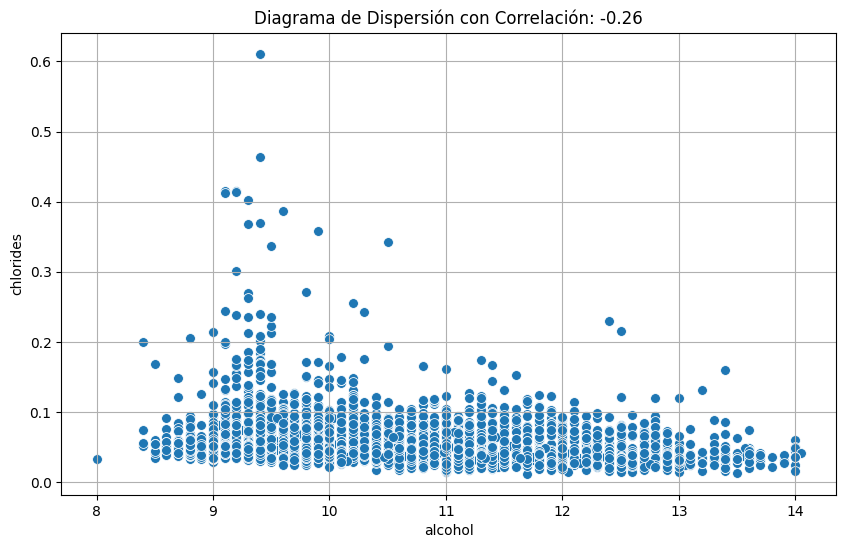

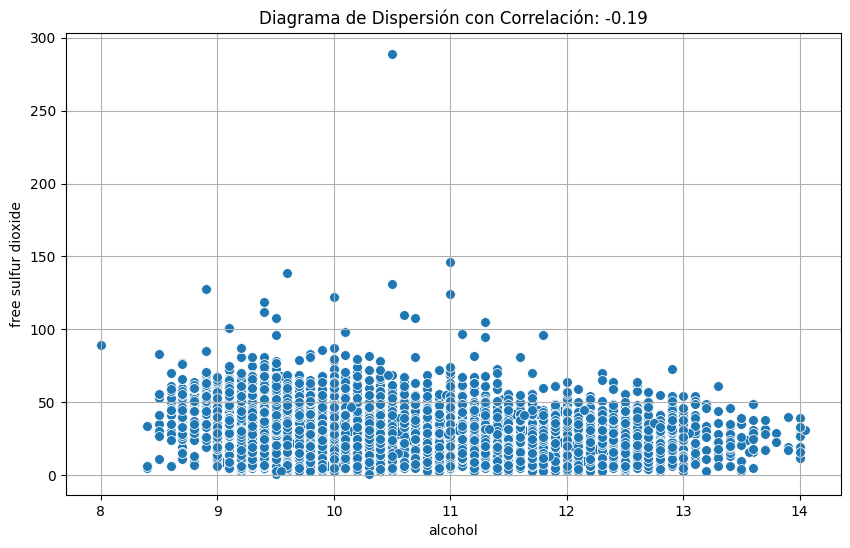

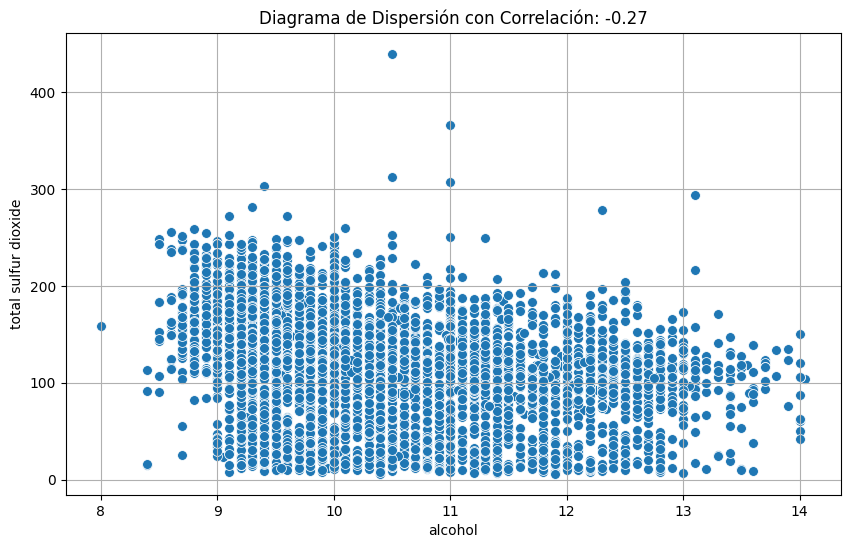

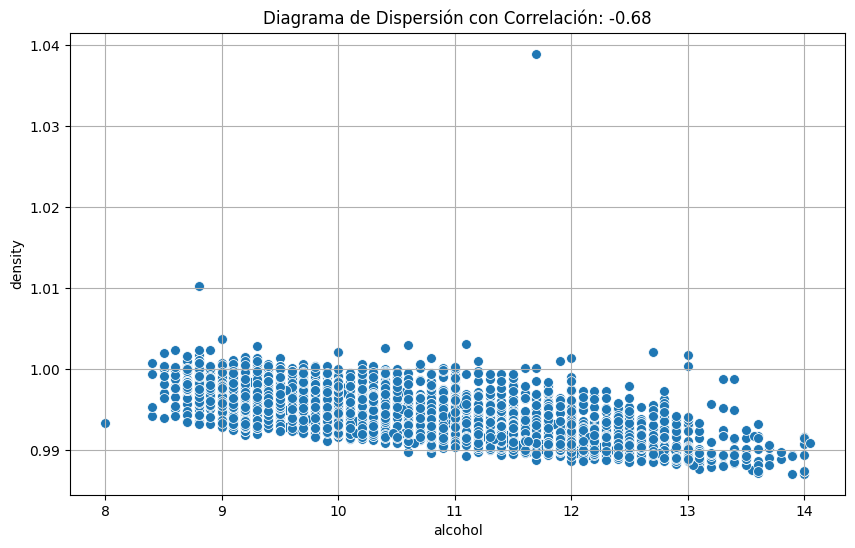

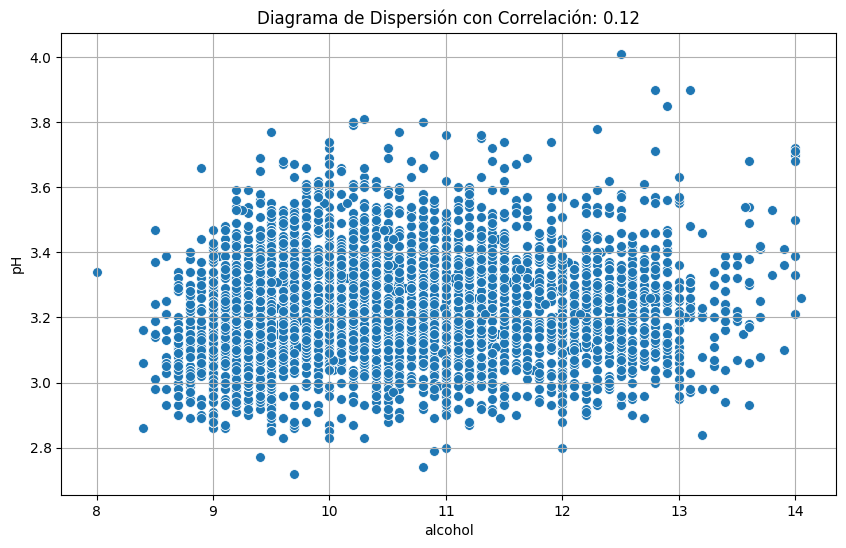

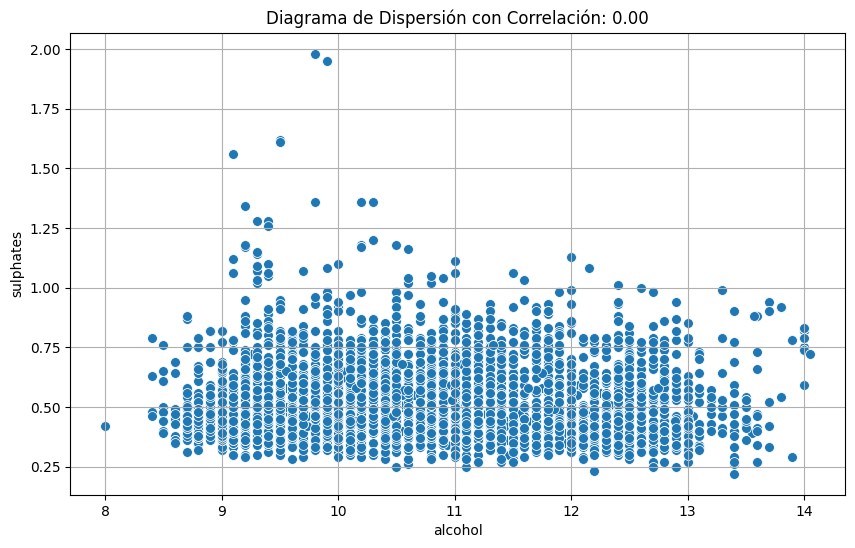

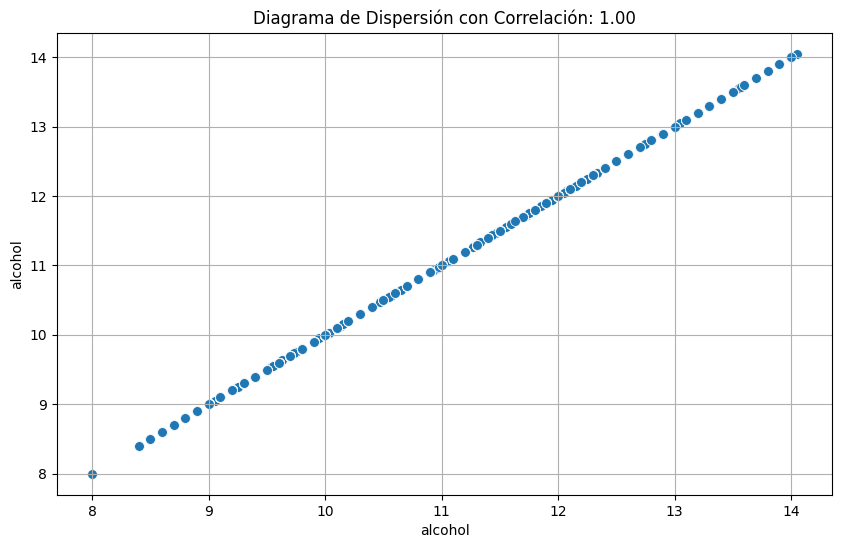

In [371]:
for numerica in numericas:    
    bt.grafico_dispersion_con_correlacion(df_reg_train, target_r,numerica, mostrar_correlacion=True)

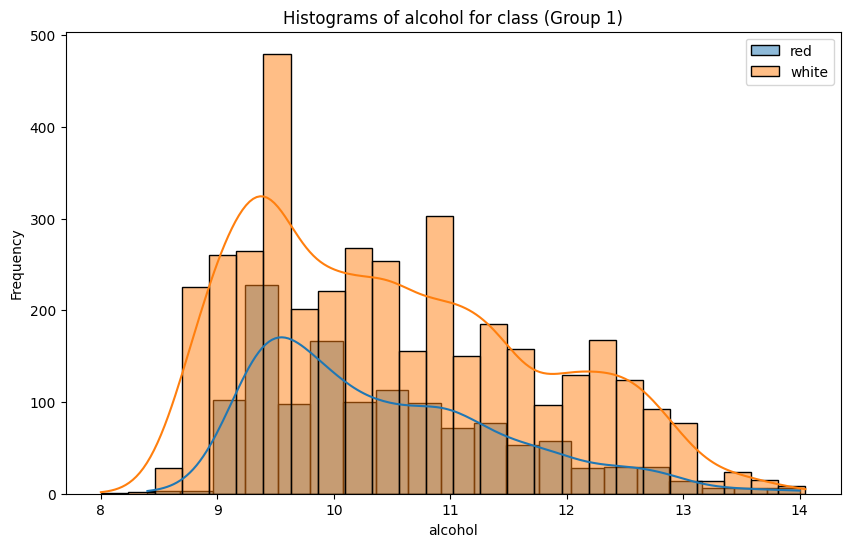

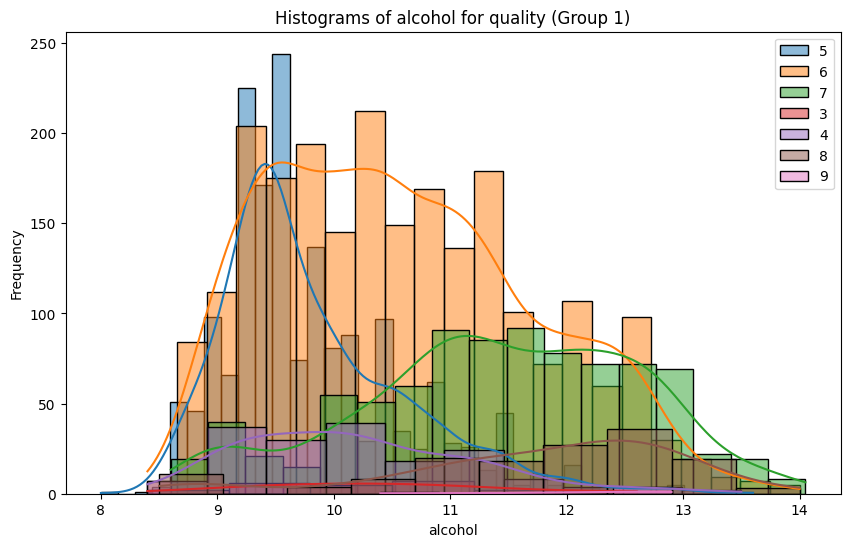

In [373]:
for categorica in categoricas2:    
    bt.plot_grouped_histograms(df_reg_train, categorica,target_r, group_size=len(categorica))

In [380]:
df_reg_train[numericas].corr()["alcohol"].abs().sort_values()

sulphates               0.000412
citric acid             0.005690
volatile acidity        0.036041
fixed acidity           0.091964
pH                      0.116497
free sulfur dioxide     0.188460
chlorides               0.260508
total sulfur dioxide    0.272970
residual sugar          0.357459
density                 0.682345
alcohol                 1.000000
Name: alcohol, dtype: float64

In [381]:
df_reg_train[numericas].columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [389]:
features = [ 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', "class","quality"]

In [383]:
df_reg_test["class"] = df_reg_test["class"]=="red"
df_reg_train["class"] = df_reg_train["class"]=="red"

In [384]:
df_reg_train_escalado = df_reg_train.copy()
df_reg_train_escalado[variables_escalar]=df_reg_train_escalado[variables_escalar].apply(lambda x: np.log(x+0.1))
df_reg_test_escalado = df_reg_test.copy()
df_reg_test_escalado[variables_escalar]=df_reg_test_escalado[variables_escalar].apply(lambda x: np.log(x+0.1))

In [385]:
escalador = StandardScaler()
df_reg_train_escalado = pd.DataFrame(escalador.fit_transform(df_reg_train_escalado[numericas]),columns=df_reg_train_escalado[numericas].columns, index = df_reg_train_escalado[numericas].index)
df_class_test_escalado = pd.DataFrame(escalador.transform(df_reg_test_escalado[numericas]),columns=df_reg_test_escalado[numericas].columns, index = df_reg_test_escalado[numericas].index)

In [386]:
df_reg_train_escalado["quality"] = df_reg_train["quality"]
df_reg_test_escalado["quality"] = df_reg_test["quality"]
df_reg_train_escalado["class"] = df_reg_train["class"]
df_reg_test_escalado["class"] = df_reg_test["class"]

In [390]:
x_train_reg = df_reg_train[features]
y_train_reg = df_reg_train[target_r]
x_test_reg = df_reg_test[features]
y_test_reg = df_reg_test[target_r]

In [391]:
x_train_reg_escaled = df_reg_train_escalado[features]
y_train_reg_escaled= df_reg_train_escalado[target_r]
x_test_reg_escalado = df_reg_test_escalado[features]
y_test_reg_escalado = df_reg_test_escalado[target_r]

In [392]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [393]:
xgbr = XGBRegressor(max_depth=10,n_estimators=300, random_state= 42 )
rfr = RandomForestRegressor(max_depth = 10, random_state= 42,n_estimators=300,n_jobs=-1)
knnr = KNeighborsRegressor(n_neighbors=5)

In [396]:
np.mean(cross_val_score(rfr, x_train_reg, y_train_reg, cv=5, n_jobs=-1, scoring="neg_mean_absolute_percentage_error"))


np.float64(-0.035878022412877006)

In [397]:
np.mean(cross_val_score(xgbr, x_train_reg, y_train_reg, cv=5, n_jobs=-1, scoring="neg_mean_absolute_percentage_error"))


np.float64(-0.030672568834104158)

In [398]:
np.mean(cross_val_score(knnr, x_train_reg, y_train_reg, cv=5, n_jobs=-1, scoring="neg_mean_absolute_percentage_error"))

np.float64(-0.07584503982675266)

In [399]:
scale_pos_weight = (y_train_class_resample == 0).sum() / (y_train_class_resample == 1).sum()

param_grid = {
    "n_estimators": [100, 200, 300],          # número de árboles
    "max_depth": [3, 5, 7],                   # profundidad máxima
    "learning_rate": [0.01, 0.05, 0.1],      # tasa de aprendizaje
    "gamma": [0, 0.1, 0.3],                   # regularización de nodo
    "reg_lambda": [1, 1.5, 2]}

In [402]:
grideo2 = GridSearchCV(xgbr, param_grid=param_grid, cv=5, n_jobs=-1,scoring="neg_mean_absolute_percentage_error")

In [403]:
grideo2.fit(x_train_reg,y_train_reg)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [404]:
xgbr_f = XGBRegressor(**grideo2.best_params_)

In [405]:
xgbr_f.fit(x_train_reg,y_train_reg)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [406]:
from sklearn.metrics import mean_absolute_percentage_error

In [407]:
mean_absolute_percentage_error(y_test_reg,xgbr_f.predict(x_test_reg))

0.029172828581140963

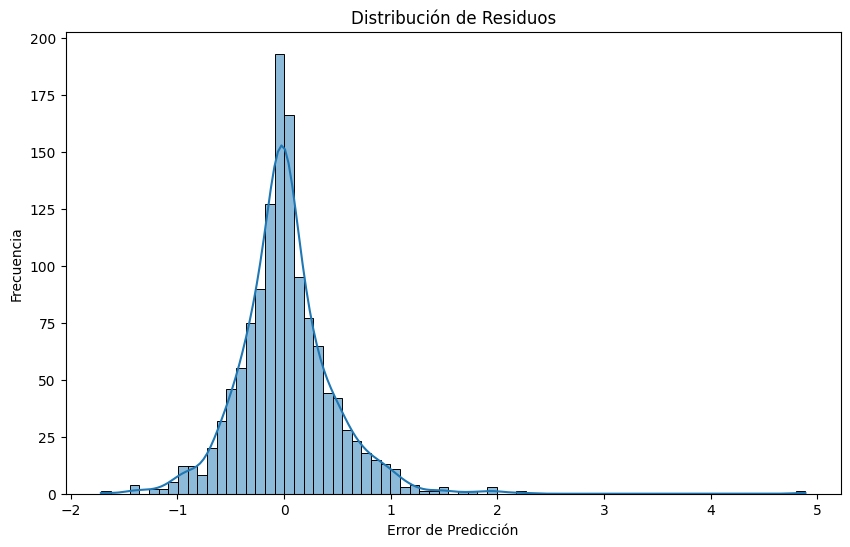

In [408]:
# Calcular residuos
residuos = y_test_reg - xgbr_f.predict(x_test_reg)

# Visualización de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Error de Predicción')
plt.ylabel('Frecuencia')
plt.show()

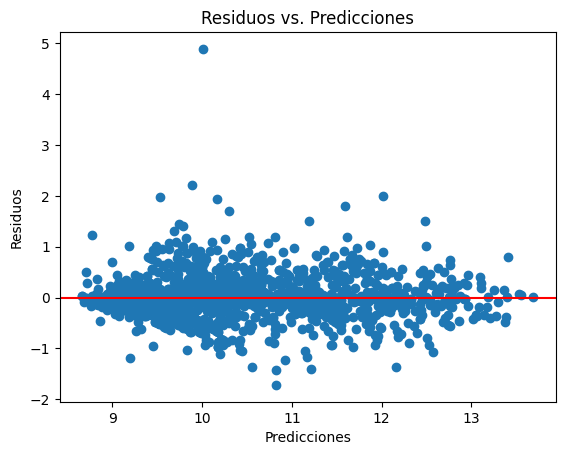

In [409]:
# Gráfica de dispersión de residuos
plt.scatter(xgbr_f.predict(x_test_reg), residuos)
plt.title('Residuos vs. Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()